# 08 - Fit an image with 2D Gaussians

The renderer is done and it has rendered a real capture. Every splat in
that capture was chosen by someone else's optimizer; nothing in this
project can choose one yet. Choosing means gradients: how the loss moves
when a mean, a scale, an angle, a color, an opacity moves. Phase C earns
them.

The full 3D pipeline stacks projection, sorting, and compositing, and
differentiating all of it at once invites errors that are miserable to
find. So strip the problem to its core: fit 2D Gaussians directly to one
image. No camera, no projection, no depth. What survives the stripping is
the over operator, and that is the part whose backward pass matters: the
recurrence derived here is, line for line, the structure inside the
official CUDA backward, and notebook 12 will reuse it unchanged.

Everything is numpy and every gradient is checked against finite
differences before it is trusted with an optimization.

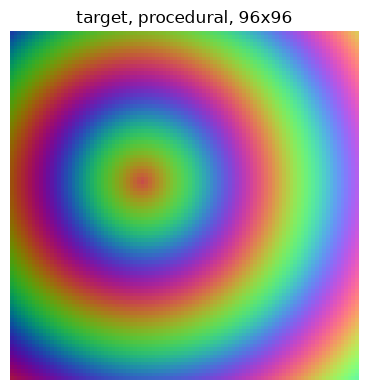

In [1]:
import numpy as np
import matplotlib.pyplot as plt

H = W = 96

yy, xx = np.mgrid[0:H, 0:W]
u = (xx - W / 2) / (W / 2)          # [-1, 1]
v = (yy - H / 2) / (H / 2)
r = np.sqrt((u + 0.25) ** 2 + (v + 0.15) ** 2)
target = np.stack([0.5 + 0.5 * np.cos(9 * r - p) for p in (0.0, 2.1, 4.2)],
                  axis=-1)
target = np.clip(0.65 * target + 0.35 * ((u + 1)[..., None] / 2), 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(target); plt.axis("off"); plt.title("target, procedural, 96x96")
plt.tight_layout(); plt.show()

## The model

K Gaussians, nine numbers each, stored raw and activated per
`docs/DECISIONS.md`:

```
mu         (2,)  pixel coords
log_s      (2,)  scale = exp(log_s), pixels
theta      (1,)  Sigma = R(theta) diag(s^2) R(theta)^T
color      (3,)  linear RGB, unconstrained
o_logit    (1,)  opacity = sigmoid(o_logit)
```

The forward pass is notebook 05's compositing restated in 2D, minus what
2D makes meaningless and minus two shortcuts, each named: no sort (there
is no depth; the array order is the compositing order), no dilation
(nothing was projected, so there is no sampling gap to guard), no bbox or
T_STOP early exit (scenes are small; keeping every pixel-splat pair makes
the backward exact and legible). The alpha floor and ceiling stay: the
floor skips invisible contributions, and the 0.99 ceiling is about to pay
off exactly as notebook 05 promised.

The forward also records what the backward will need: every alpha map,
the two clamp gates, and the final transmittance. That trio is the entire
tape; the intermediate transmittances are deliberately absent.

In [2]:
ALPHA_MIN = 1.0 / 255
ALPHA_MAX = 0.99

def activate(params):
    return (params["mu"], np.exp(params["log_s"]), params["theta"],
            params["color"], 1.0 / (1.0 + np.exp(-params["o_logit"])))

def conic_of(s, theta):
    """Per-splat inverse covariance from scale and angle, (K, 2, 2)."""
    c, n = np.cos(theta), np.sin(theta)
    R = np.stack([np.stack([c, -n], -1), np.stack([n, c], -1)], -2)
    Sig = R @ (s[..., None] ** 2 * np.eye(2)) @ np.swapaxes(R, -1, -2)
    det = Sig[..., 0, 0] * Sig[..., 1, 1] - Sig[..., 0, 1] * Sig[..., 1, 0]
    inv = np.empty_like(Sig)
    inv[..., 0, 0] = Sig[..., 1, 1]
    inv[..., 1, 1] = Sig[..., 0, 0]
    inv[..., 0, 1] = inv[..., 1, 0] = -Sig[..., 0, 1]
    return inv / det[..., None, None], Sig

def forward(params, H, W, alpha_min=ALPHA_MIN):
    """Composite front (k=0) to back (k=K-1). Returns image and tape."""
    mu, s, theta, color, opa = activate(params)
    A, Sig = conic_of(s, theta)
    K = len(mu)
    ys, xs = np.mgrid[0:H, 0:W]
    img = np.zeros((H, W, 3))
    T = np.ones((H, W))
    alphas = np.zeros((K, H, W))
    live = np.zeros((K, H, W), bool)      # alpha in (min, max): grads flow
    for k in range(K):
        dx, dy = xs - mu[k, 0], ys - mu[k, 1]
        power = -0.5 * (A[k, 0, 0] * dx * dx + A[k, 1, 1] * dy * dy) \
                - A[k, 0, 1] * dx * dy
        a = opa[k] * np.exp(power)
        capped = a > ALPHA_MAX
        a = np.where(capped, ALPHA_MAX, a)
        a = np.where(a < alpha_min, 0.0, a)
        live[k] = (a > 0) & ~capped
        alphas[k] = a
        img += (T * a)[..., None] * color[k]
        T = T * (1.0 - a)
    return img, (alphas, live, T, A, Sig)

def mse(img, target):
    return np.mean((img - target) ** 2)

def psnr(img, target):
    return -10.0 * np.log10(mse(np.clip(img, 0, 1), target))

Initialization is the break made visible. Means scattered uniformly,
scales a few pixels, angles random, low opacity, and each color sampled
from the target under its mean (the same trick 3DGS borrows from SfM
points, and still nowhere near the target).

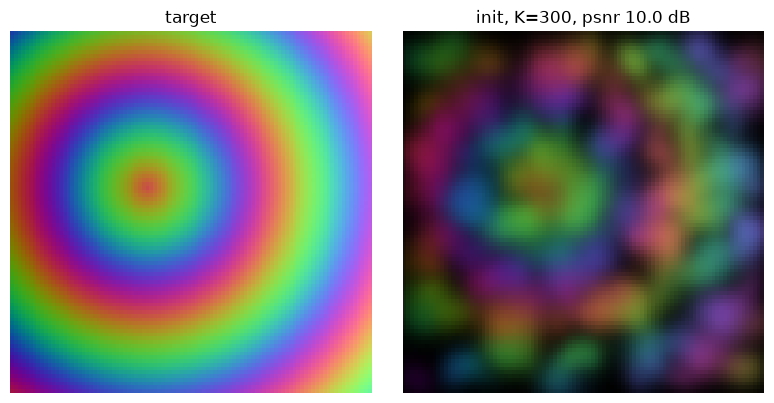

In [3]:
K = 300

def init_params(K, rng):
    mu = np.stack([rng.uniform(2, W - 2, K), rng.uniform(2, H - 2, K)], -1)
    col = target[mu[:, 1].astype(int), mu[:, 0].astype(int)].copy()
    return {"mu": mu,
            "log_s": np.log(rng.uniform(2.5, 5.0, (K, 2))),
            "theta": rng.uniform(0, np.pi, K),
            "color": col,
            "o_logit": np.full(K, np.log(0.25 / 0.75))}

rng = np.random.default_rng(8)
params = init_params(K, rng)
img0, _ = forward(params, H, W)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(target); axes[0].set_title("target")
axes[1].imshow(np.clip(img0, 0, 1))
axes[1].set_title(f"init, K={K}, psnr {psnr(img0, target):.1f} dB")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Backward, derived

Loss first. With `P = H*W*3` scalar outputs,

$$L = \frac{1}{P} \sum_p (C_p - \text{target}_p)^2
\qquad\Longrightarrow\qquad
\frac{\partial L}{\partial C} = \frac{2}{P} (C - \text{target})$$

Now through the over operator. Per pixel, with
$T_i = \prod_{j<i} (1 - a_j)$:

$$C = \sum_i c_i a_i T_i$$

Color is the easy half: $c_i$ appears once, weighted by its own
contribution, so
$\partial L / \partial c_i = \sum_\text{pixels} (\partial L/\partial C)
\, a_i T_i$.

Alpha is the interesting half. $a_i$ appears directly in its own term and
inside $T_j$ of every splat behind it, through the factor $(1 - a_i)$:

$$\frac{\partial C}{\partial a_i}
= c_i T_i - \frac{1}{1 - a_i} \sum_{j>i} c_j a_j T_j$$

Call that trailing sum $S_i$, the color blended behind splat $i$. Walking
splats back to front maintains $S_i$ as a running accumulation for free.

## Exercise

The formula also wants every $T_i$, and the forward pass deliberately kept
only the final transmittance $T_K = \prod_j (1 - a_j)$. Storing all K maps
is exactly what a CUDA kernel cannot afford. Recover each $T_i$ from
$T_K$ and the alphas alone, walking back to front, and state what makes
the recovery numerically safe. Work it before scrolling.

## Solution

Divide out one factor per step:

$$T_i = \frac{T_\text{run}}{1 - a_i}$$

concretely: $T_\text{run}$ starts at $T_K$; at splat $i$ (last to first),
$T_i = T_\text{run} / (1 - a_i)$, and $T_\text{run}$ becomes $T_i$ for the
next step.
Safe because notebook 05 capped alpha at 0.99: the divisor never drops
below 0.01. That cap was installed two notebooks ago for this division;
the official backward (`render_backward` in `diff-gaussian-rasterization`)
stores final T and divides the same way.

## Backward, the rest of the chain

From $\partial L / \partial a_i$ down to the nine raw numbers, outermost to
innermost. The kernel is $a = o g$, $g = \exp(\text{power})$:

$$\frac{\partial L}{\partial o}
= \sum_\text{pixels} \frac{\partial L}{\partial a} g,
\qquad \frac{\partial o}{\partial \text{logit}} = o (1 - o)$$

$$\frac{\partial L}{\partial \text{power}}
= \frac{\partial L}{\partial a} o g
= \frac{\partial L}{\partial a} a$$

$\text{power} = -\tfrac{1}{2} d^{T} A d$ with $d = \text{pixel} - \mu$
and $A$ the conic:

$$\frac{\partial \text{power}}{\partial \mu} = A d
\qquad\text{(the minus from } d(-d)/d\mu
\text{ cancels the } -\tfrac{1}{2}\text{'s 2)}$$

$$\frac{\partial \text{power}}{\partial A}
= -\tfrac{1}{2} d d^{T}$$

$A = \Sigma^{-1}$ is the one genuinely new piece of matrix calculus. From
$A \Sigma = I$: $dA = -A \, d\Sigma \, A$, so gradients transpose-chain as

$$\frac{\partial L}{\partial \Sigma}
= -A \left(\frac{\partial L}{\partial A}\right) A
\qquad (A \text{ symmetric})$$

and $\Sigma = R \, \mathrm{diag}(s^2) \, R^{T}$ closes the chain. With
$r_m$ the m-th column of $R$ and $R' = dR/d\theta$:

$$\frac{\partial L}{\partial s_m}
= 2 s_m r_m^{T} \left(\frac{\partial L}{\partial \Sigma}\right) r_m,
\qquad \frac{ds}{d\log s} = s$$

$$\frac{\partial L}{\partial \theta}
= \frac{\partial L}{\partial \Sigma} :
(R' D R^{T} + R D R'^{T}), \qquad D = \mathrm{diag}(s^2)$$

Both clamps gate everything: a pixel where alpha was floored to zero or
capped at 0.99 contributes no kernel gradient there (the computed
function is locally constant in that region). The `live` mask from the
forward is that gate.

In [4]:
def backward(params, target, H, W, alpha_min=ALPHA_MIN):
    """Returns (loss, image, grads) with grads matching params' keys."""
    mu, s, theta, color, opa = activate(params)
    img, (alphas, live, T_final, A, Sig) = forward(params, H, W, alpha_min)
    K = len(mu)
    P = img.size
    dLdC = (2.0 / P) * (img - target)              # (H, W, 3)

    ys, xs = np.mgrid[0:H, 0:W]
    g = {k: np.zeros_like(v) for k, v in params.items()}
    S = np.zeros((H, W, 3))                        # color blended behind i
    T_run = T_final.copy()
    c_th, s_th = np.cos(theta), np.sin(theta)
    for k in range(K - 1, -1, -1):
        a = alphas[k]
        one_m = 1.0 - a
        T_k = T_run / one_m
        w = a * T_k
        g["color"][k] = np.einsum("hwc,hw->c", dLdC, w)

        dCda = T_k[..., None] * color[k] - S / one_m[..., None]
        dLda = np.einsum("hwc,hwc->hw", dLdC, dCda) * live[k]

        kern = a / opa[k]                          # = exp(power) where live
        g["o_logit"][k] = np.sum(dLda * kern) * opa[k] * (1.0 - opa[k])

        dLdp = dLda * a                            # dL/dpower
        dx, dy = xs - mu[k, 0], ys - mu[k, 1]
        Ad_x = A[k, 0, 0] * dx + A[k, 0, 1] * dy
        Ad_y = A[k, 1, 0] * dx + A[k, 1, 1] * dy
        g["mu"][k] = [np.sum(dLdp * Ad_x), np.sum(dLdp * Ad_y)]

        dLdA = -0.5 * np.array([
            [np.sum(dLdp * dx * dx), np.sum(dLdp * dx * dy)],
            [np.sum(dLdp * dy * dx), np.sum(dLdp * dy * dy)]])
        dLdSig = -A[k] @ dLdA @ A[k]

        R = np.array([[c_th[k], -s_th[k]], [s_th[k], c_th[k]]])
        Rp = np.array([[-s_th[k], -c_th[k]], [c_th[k], -s_th[k]]])
        D = np.diag(s[k] ** 2)
        for m in range(2):
            g["log_s"][k, m] = 2 * s[k, m] ** 2 * (R[:, m] @ dLdSig @ R[:, m])
        g["theta"][k] = np.sum(dLdSig * (Rp @ D @ R.T + R @ D @ Rp.T))

        S = S + w[..., None] * color[k]
        T_run = T_k
    return mse(img, target), img, g

## Checked before trusted

Two checks. The matrix-inverse differential gets its own, on random SPD
matrices, because it is the step most worth isolating. Then the full
backward runs against central finite differences on a tiny float64
configuration: 3 Gaussians, 16x16, every one of the 27 parameters. The
alpha floor is switched off for the check (a step function has no useful
finite difference at its threshold; training keeps it on, where its
gradient gate is simply zero).

In [5]:
rng_c = np.random.default_rng(0)
for _ in range(10):
    Mh = rng_c.normal(size=(2, 2))
    Sp = Mh @ Mh.T + 0.5 * np.eye(2)
    dS = rng_c.normal(size=(2, 2)); dS = dS + dS.T
    eps = 1e-6
    fd = (np.linalg.inv(Sp + eps * dS) - np.linalg.inv(Sp - eps * dS)) / (2 * eps)
    an = -np.linalg.inv(Sp) @ dS @ np.linalg.inv(Sp)
    assert np.allclose(fd, an, rtol=1e-5, atol=1e-8)
print("d(Sigma^-1) = -Sigma^-1 dSigma Sigma^-1 holds")

d(Sigma^-1) = -Sigma^-1 dSigma Sigma^-1 holds


In [6]:
rng_g = np.random.default_rng(1)
tiny_t = rng_g.uniform(0.2, 0.8, (16, 16, 3))
tp = {"mu": rng_g.uniform(4, 12, (3, 2)),
      "log_s": np.log(rng_g.uniform(1.5, 3.0, (3, 2))),
      "theta": rng_g.uniform(0, np.pi, 3),
      "color": rng_g.uniform(0.1, 0.9, (3, 3)),
      "o_logit": rng_g.uniform(-0.5, 1.0, 3)}

_, _, grads = backward(tp, tiny_t, 16, 16, alpha_min=0.0)
eps = 1e-6
worst = 0.0
for key in tp:
    flat = tp[key].reshape(-1)
    for i in range(flat.size):
        keep = flat[i]
        flat[i] = keep + eps
        lp, _, _ = backward(tp, tiny_t, 16, 16, alpha_min=0.0)
        flat[i] = keep - eps
        lm, _, _ = backward(tp, tiny_t, 16, 16, alpha_min=0.0)
        flat[i] = keep
        fd = (lp - lm) / (2 * eps)
        an = grads[key].reshape(-1)[i]
        rel = abs(fd - an) / max(abs(fd), abs(an), 1e-12)
        worst = max(worst, rel)
        assert rel < 1e-4, f"{key}[{i}]: fd {fd:.3e} vs analytic {an:.3e}"
print(f"gradcheck: 27/27 parameters pass, worst rel err {worst:.1e}")

gradcheck: 27/27 parameters pass, worst rel err 5.2e-08


## Adam, in numpy

The optimizer 3DGS uses, nothing removed: first and second moment
averages with bias correction, betas 0.9 and 0.999, eps 1e-8. Learning
rates differ per parameter group, exactly as in the official trainer,
because a pixel of mean motion and a unit of color live on different
scales. Means get 2e-3 in normalized image coordinates, so 2e-3 * W in
pixels; color 1e-2; scales, angle, and opacity 5e-3. These are the
roadmap's starting points; they fit this target without retuning.

In [7]:
LR = {"mu": 2e-3 * W, "color": 1e-2, "log_s": 5e-3,
      "theta": 5e-3, "o_logit": 5e-3}

class Adam:
    def __init__(self, params, lr, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            mhat = self.m[k] / (1 - self.b1 ** self.t)
            vhat = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr[k] * mhat / (np.sqrt(vhat) + self.eps)

In [8]:
STEPS = 600
opt = Adam(params, LR)
losses, snaps, snap_at = [], {}, [0, 30, 100, 300, STEPS - 1]
for it in range(STEPS):
    loss, img, grads = backward(params, target, H, W)
    losses.append(loss)
    if it in snap_at:
        snaps[it] = img
    opt.step(params, grads)
    if it % 100 == 0 or it == STEPS - 1:
        print(f"step {it:4d}  loss {loss:.5f}  psnr {psnr(img, target):.2f} dB")

assert np.all(np.diff(losses[:51]) < 0), "loss must fall monotonically early"
final_img, _ = forward(params, H, W)
print(f"final: psnr {psnr(final_img, target):.2f} dB")
assert psnr(final_img, target) > 20.0

step    0  loss 0.10105  psnr 9.95 dB


step  100  loss 0.00102  psnr 29.96 dB


step  200  loss 0.00022  psnr 36.68 dB


step  300  loss 0.00010  psnr 39.94 dB


step  400  loss 0.00007  psnr 41.85 dB


step  500  loss 0.00005  psnr 43.20 dB


step  599  loss 0.00004  psnr 44.25 dB
final: psnr 44.26 dB


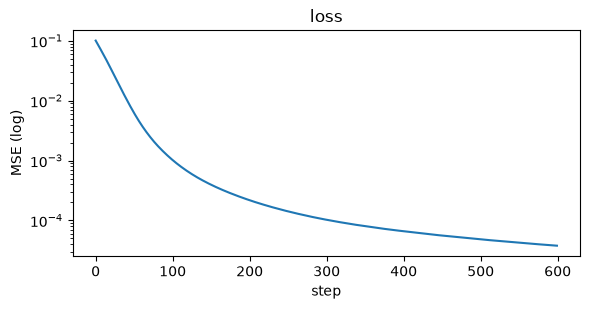

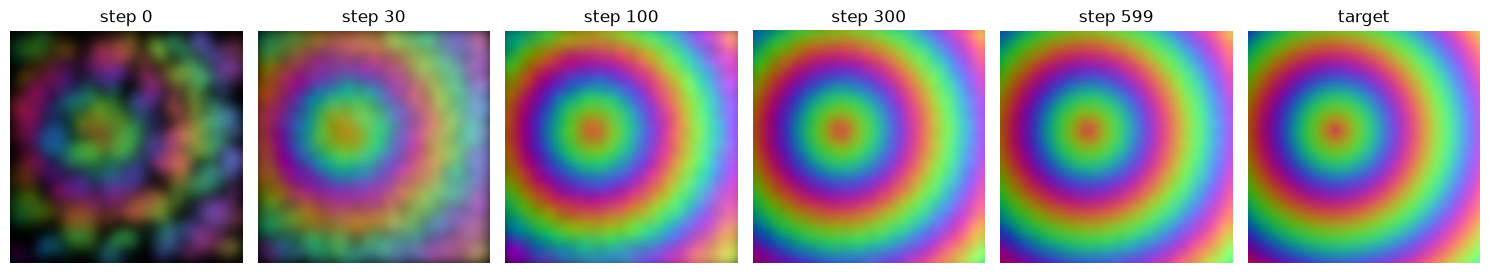

In [9]:
plt.figure(figsize=(6, 3.2))
plt.semilogy(losses)
plt.xlabel("step"); plt.ylabel("MSE (log)"); plt.title("loss")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(snap_at) + 1, figsize=(15, 2.9))
for ax, it in zip(axes, snap_at):
    ax.imshow(np.clip(snaps[it], 0, 1)); ax.set_title(f"step {it}")
axes[-1].imshow(target); axes[-1].set_title("target")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

Six hundred steps take the random soup past 40 dB, visually identical to
the target. The middle of the montage is the part worth staring at: the
rings emerge because the gradient stretches and orients individual splats
along them, exactly the anisotropy the covariance parameterization was
built to express. This is the entire mechanism of 3DGS training; the
loss, the recurrence, the clamps, the per-group learning rates all carry
over unchanged. The same pipeline lives in
`train/train_2d.py` as a script (`python train/train_2d.py --help`), for
runs longer than a notebook cell should hold.

## The next live problem

Two things fell out of reach of this sandbox. First, dimensionality: the
real pipeline optimizes 3D means, quaternions, and 3D scales through the
EWA projection and a depth sort, and hand-deriving that full chain is
genuinely phase D's job, where each formula lands inside a kernel.
Second, honesty about cost: this notebook spent minutes fitting one tiny
image. Notebook 09 rebuilds the forward pass in PyTorch, lets autograd
own every gradient just derived by hand (checked against the same finite
differences), trains a real 3D scene from rendered ground truth, and
measures the wall-clock bill that makes CUDA unavoidable.